# Laboratory work 3

## Modeling a Bayesian classifier for Gaussian random vectors

Importing libs


In [440]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Making class to work with Bayesian classifier

In [441]:
from collections.abc import Callable

class BayesianClassifier:
    def __init__(self, N: int, L:int):
        self.N = N
        self.L = L
        self.a_priori_probabilities = []
        self.conditional_densities = []

    def _gaussian_density_one_point(self, mu: np.ndarray, sigma: np.ndarray)->Callable:
        density = lambda x: (2 * np.pi) ** (-self.N/2) * np.linalg.det(sigma) ** (-1/2) \
            * np.exp(-(x - mu).T @ np.linalg.inv(sigma) @ (x - mu) / 2)
        return density

    def gaussian_density(self, mu: np.ndarray, sigma:np.ndarray)->list[Callable]:
        densities = []
        for i in range(self.L):
            densities.append(self._gaussian_density_one_point(mu[i], sigma[i]))
        
        return densities
    
    def set_probability_characteristics(self, apriory_probabilities: list[float],
                                         conditional_densities: list[Callable])->None:
        self.a_priori_probabilities = apriory_probabilities
        self.conditional_densities = conditional_densities

    def probabilities(self, x: np.ndarray)->list[float]:
        a_posteriori_probabilities: list[float] = []
        f: list[float] = []
        for i in range(self.L):
            f.append(self.a_priori_probabilities[i] * self.conditional_densities[i](x))

        summ = sum(f)
        for i in range(self.L):
            a_posteriori_probabilities.append(f[i] / summ)

        return a_posteriori_probabilities
    
    def fit(self, X: np.ndarray, y: np.ndarray)->None:
        self.a_priori_probabilities = []
        self.densities = []
        for i in range(self.L):
            mask = (y == (i+1))
            count = len(y[mask])
            self.a_priori_probabilities.append(count / len(y))

            mean = np.mean(X[mask], axis=0)
            cov = np.cov(X[mask], rowvar=False)
            density = self._gaussian_density_one_point(mean, cov)
            self.densities.append(density)
        return None
    
    def _predict_one_point(self, x: np.ndarray)->int:
        return int(np.argmax(self.probabilities(x))) + 1
    
    def predict(self, x: np.ndarray)->np.ndarray:
        y = np.array([self._predict_one_point(i) for i in x])
        return y

Declarating function to draw ellipsoid of conditional gaussian densities

In [442]:
from scipy.stats import chi2
from matplotlib.patches import Ellipse

def plot_ellipsoid(ax, mu: np.ndarray, sigma: np.ndarray, color: str, alpha=0.95):
    chi2_val = chi2.ppf(alpha, df=2)
    eigvals, eigvecs = np.linalg.eigh(sigma)
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width = 2 * np.sqrt(eigvals[0] * chi2_val)
    height = 2 * np.sqrt(eigvals[1] * chi2_val)
    
    ell = Ellipse(xy=mu.tolist(), width=width, height=height, angle=angle, color=color, alpha=0.5)
    ax.add_patch(ell)

In [443]:
def plot_decision_boundary(ax, bc: BayesianClassifier, xlim, ylim, n_grid=300):
    """Рисует разделяющую кривую байесовского классификатора."""
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], n_grid),
                         np.linspace(ylim[0], ylim[1], n_grid))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = bc.predict(grid)
    Z = Z.reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=np.arange(-0.5, 2+0.5, 1),
               colors='black', linewidths=1.5, linestyles='--')

In [444]:
def generate_sample(n_classes: int, mus: np.ndarray, sigmas: np.ndarray, n_samples: int)->pd.DataFrame:
    dfs = []
    for i in range(n_classes):
        random_variables = np.random.multivariate_normal(mus[i], sigmas[i], n_samples // n_classes)
        columns_names = [f"x_{j+1}" for j in range(random_variables.shape[1])]
        buff_df = pd.DataFrame(random_variables, columns=columns_names)
        buff_df['label'] = i + 1
        dfs.append(buff_df)
    df: pd.DataFrame = pd.concat(dfs, ignore_index=True)
    df = df.sample(frac=1).reset_index(drop=True)
    return df

In [445]:
def accuracy_rate(y_true: np.ndarray, y_pred: np.ndarray)->float:
    return (y_true == y_pred).sum() / len(y_true)

### 1. All probability characteristics are known.

$N=2, L=2, \pi_1 = \pi_2 = 0.5, M_i=M_i'=20, i=1,2, K=20$

$\mu_1 = (-1, -1)^T,\ \mu_2=(1, 1)^T$

In [446]:
bc = BayesianClassifier(2, 2)
a_priori = [0.5, 0.5]
mu_1 = np.array([-1, -1])
mu_2 = np.array([1, 1])
mus = np.stack((mu_1, mu_2))

A) $\Sigma_1=\Sigma_2=\begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$

In [447]:
sigma = np.array([[1, 0], [0, 1]])
sigmas_a = np.stack((sigma, sigma))

In [448]:
df_test = generate_sample(2, mus, sigmas_a, 20)
df_test.head()

,x_1,x_2,label
0,-0.210965,-1.456941,1
1,0.697640,0.815012,2
2,-0.769308,-1.374661,1
3,-0.910996,0.239915,1
4,-0.908781,-1.771278,1


In [449]:
densities = bc.gaussian_density(mus, sigmas_a)

bc.set_probability_characteristics(a_priori, densities)
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(0.95)

In [450]:
n_samples = 20

df_train = generate_sample(2, mus, sigmas_a, n_samples)
df_train.head()

,x_1,x_2,label
0,1.336428,1.817875,2
1,2.125712,1.412223,2
2,0.608366,0.410859,2
3,-0.164726,-0.118328,2
4,-2.535163,-2.662075,1


In [451]:
bc.fit(df_train.iloc[:, :-1].to_numpy(), df_train['label'].to_numpy())
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(0.95)

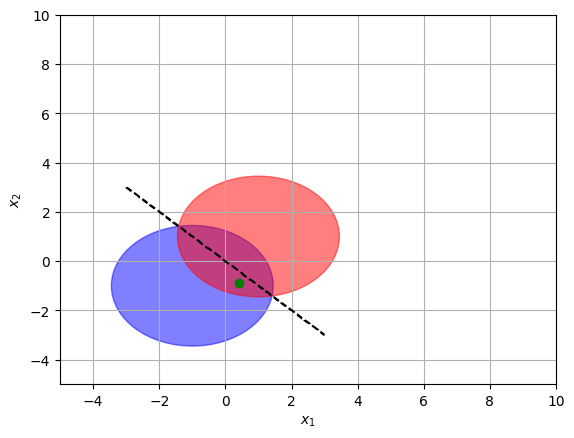

In [452]:
df_wrong = df_test[y_pred != df_test['label']][['x_1', 'x_2']]

fig, ax = plt.subplots()
plot_ellipsoid(ax, mu_1, sigma, 'blue')
plot_ellipsoid(ax, mu_2, sigma, 'red')
plt.scatter(x = df_wrong['x_1'], y=df_wrong['x_2'], color='green')
plot_decision_boundary(ax, bc, [-3, 3], [-3, 3])

plt.xlim(-5, 10)
plt.xlabel(r"$x_1$")
plt.ylim(-5, 10)
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

B) $\Sigma_1 = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$, $\Sigma_2 = \begin{pmatrix} 2 & 0 \\ 0 & 2 \end{pmatrix}$

In [453]:
sigma_b1 = np.array([[1, 0], [0, 1]])
sigma_b2 = np.array([[2, 0], [0, 2]])
sigmas_b = np.stack((sigma_b1, sigma_b2))
densities = bc.gaussian_density(mus, sigmas_b)

In [454]:
df_test = generate_sample(2, mus, sigmas_b, n_samples)
df_test.head()

,x_1,x_2,label
0,0.421410,1.865432,2
1,0.197218,1.643078,2
2,-1.700715,-1.581599,1
3,-0.941334,-1.316731,1
4,-1.021050,-1.003411,1


In [455]:
bc.set_probability_characteristics(a_priori, densities)
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(0.9)

In [456]:
n_samples = 20
df_train = generate_sample(2, mus, sigmas_b, n_samples)
df_train.head()

,x_1,x_2,label
0,-2.207057,-1.393287,1
1,-0.776341,0.051404,2
2,-2.605268,-1.577422,1
3,-1.870716,-0.373581,1
4,-0.637788,0.724085,1


In [457]:
bc.fit(df_train.iloc[:, :-1].to_numpy(), df_train['label'].to_numpy())
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].values, y_pred)

np.float64(0.9)

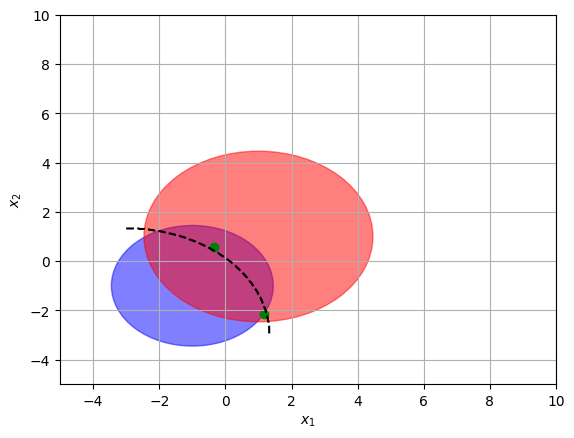

In [458]:
df_wrong = df_test[y_pred != df_test['label']][['x_1', 'x_2']]

fig, ax = plt.subplots()
plot_ellipsoid(ax, mu_1, sigma_b1, 'blue')
plot_ellipsoid(ax, mu_2, sigma_b2, 'red')
plt.scatter(x = df_wrong['x_1'], y=df_wrong['x_2'], color='green')
plot_decision_boundary(ax, bc, [-3, 3], [-3, 3])
plt.xlim(-5, 10)
plt.xlabel(r"$x_1$")
plt.ylim(-5, 10)
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

C) $\Sigma_1 = \begin{pmatrix} 1 & 0.5 \\ 0.5 & 1 \end{pmatrix}$, $\Sigma_2 = \begin{pmatrix} 2 & -1.5 \\ -1.5 & 2 \end{pmatrix}$

In [459]:
sigma_c1 = np.array([[1, 0.5], [0.5, 1]])
sigma_c2 = np.array([[2, -1.5], [-1.5, 2]])
sigmas_c = np.stack((sigma_c1, sigma_c2))
densities = bc.gaussian_density(mus, sigmas_c)

In [460]:
df_test = generate_sample(2, mus, sigmas_a, n_samples)
df_test.head()

,x_1,x_2,label
0,1.119372,0.237600,2
1,1.158628,0.130681,2
2,-0.788156,-0.054718,1
3,2.960503,0.175907,2
4,3.468640,0.151267,2


In [461]:
bc.set_probability_characteristics(a_priori, densities)
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(1.0)

In [462]:
n_samples = 20
df_train = generate_sample(2, mus, sigmas_c, n_samples)
df_train.head()

,x_1,x_2,label
0,-0.519416,0.301669,1
1,0.698878,0.565783,2
2,-2.250370,-2.407694,1
3,-2.675690,-2.196073,1
4,-2.007131,-1.376670,1


In [463]:
bc.fit(df_train.iloc[:, :-1].to_numpy(), df_train['label'].to_numpy())
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(1.0)

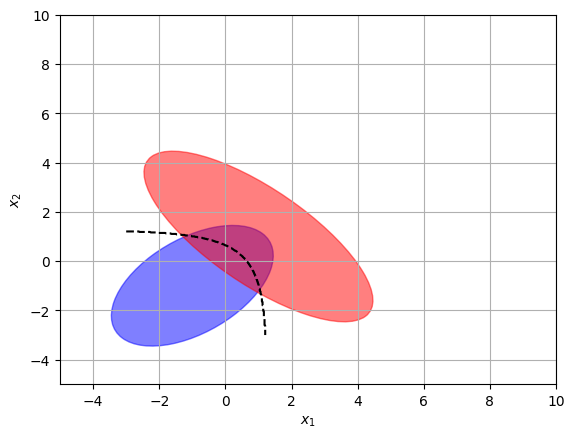

In [464]:
df_wrong = df_test[y_pred != df_test['label']][['x_1', 'x_2']]

fig, ax = plt.subplots()
plot_ellipsoid(ax, mu_1, sigma_c1, 'blue')
plot_ellipsoid(ax, mu_2, sigma_c2, 'red')
plt.scatter(x = df_wrong['x_1'], y=df_wrong['x_2'], color='green')
plot_decision_boundary(ax, bc, [-3, 3], [-3, 3])
plt.xlim(-5, 10)
plt.xlabel(r"$x_1$")
plt.ylim(-5, 10)
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

$N=2, L=4, \pi_1 = \pi_i = 0.25, M_i=M_i'=20, i=\overline{1,4}, K=20$

$\mu_1 = (-1, -1)^T,\ \mu_2=(-1, 1)^T,\ \mu_3=(1, 1)^T,\ \mu_4=(1,-1)^T$

$\Sigma_1 = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix},\ \Sigma_2 = \begin{pmatrix} 1 & 0.5 \\ 0.5 & 1 \end{pmatrix},\ \Sigma_3 = \begin{pmatrix} 2 & 0 \\ 0 & 2 \end{pmatrix},\ \Sigma_4 = \begin{pmatrix} 1 & -0.5 \\ -0.5 & 1 \end{pmatrix}$

In [465]:
bc2 = BayesianClassifier(N=2, L=4)
a_priori = [0.25, 0.25, 0.25, 0.25]

mu_1 = np.array([-1, -1])
mu_2 = np.array([-1, 1])
mu_3 = np.array([1, 1])
mu_4 = np.array([1, -1])
mus_2 = np.stack((mu_1, mu_2, mu_3, mu_4))

sigma_1 = np.array([[1, 0], [0, 1]])
sigma_2 = np.array([[1, 0.5], [0.5, 1]])
sigma_3 = np.array([[2, 0], [0, 2]])
sigma_4 = np.array([[1, -0.5], [-0.5, 1]])
sigmas_2 = np.stack((sigma_1, sigma_2, sigma_3, sigma_4))

In [466]:
df_test = generate_sample(4, mus_2, sigmas_2, n_samples)
df_test.head()

,x_1,x_2,label
0,2.573461,1.058742,3
1,-1.524138,-2.145134,1
2,0.161190,0.367793,4
3,1.411324,2.344069,3
4,1.234165,-2.215186,4


In [467]:
densities = bc2.gaussian_density(mus_2, sigmas_2)
bc2.set_probability_characteristics(a_priori, densities)

y_pred = bc2.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(0.75)

In [468]:
n_samples = 20
df_train = generate_sample(4, mus_2, sigmas_2, n_samples)
df_train.head()

,x_1,x_2,label
0,1.645355,-1.540496,4
1,-1.170905,1.201363,2
2,0.588525,-1.871257,1
3,-2.060129,-2.345404,1
4,-2.691917,-1.061961,1


In [469]:
bc2.fit(df_train.iloc[:, :-1].to_numpy(), df_train['label'].to_numpy())
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(0.3)

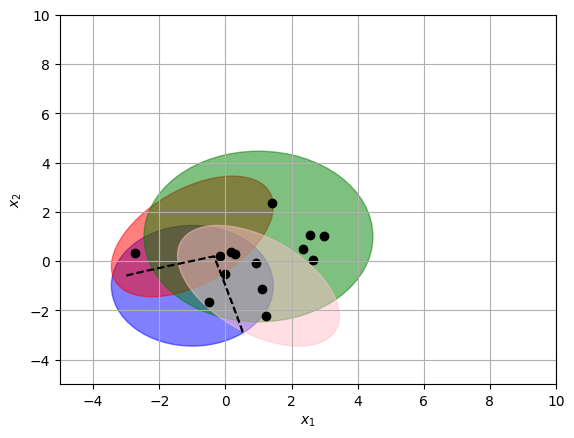

In [471]:
df_wrong = df_test[y_pred != df_test['label']][['x_1', 'x_2']]

fig, ax = plt.subplots()
plot_ellipsoid(ax, mu_1, sigma_1, 'blue')
plot_ellipsoid(ax, mu_2, sigma_2, 'red')
plot_ellipsoid(ax, mu_3, sigma_3, 'green')
plot_ellipsoid(ax, mu_4, sigma_4, 'pink')
plt.scatter(x = df_wrong['x_1'], y=df_wrong['x_2'], color='black')
plot_decision_boundary(ax, bc2, [-3, 3], [-3, 3])
plt.xlim(-5, 10)
plt.xlabel(r"$x_1$")
plt.ylim(-5, 10)
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()